## Dataset **MNIST** (Modified National Institute of Standards and Technology)

- **Contenu** : Images de chiffres manuscrits (**0 à 9**)  
- **Taille** : **70 000** images au total  
  - <span style="color:cyan;">**Ensemble d'entraînement**</span> : **60 000** images
         - Ensemble d'entraînement (Train, Calibration, Validation) : 75%
  - <span style="color:orange;">**Ensemble de test**</span> : **10 000** images  
-  **Format des images** :  
  - Résolution : **28×28 pixels**  
  - Niveaux de gris (**0 = noir, 255 = blanc**)  
- **Labels** : **Chiffres de 0 à 9** (**10 classes**)  



## **Méthodes Conformal Prediction : SAPS, RAPS, APS**  

### **1. APS (Adaptive Prediction Sets)**
### **2. SAPS (Sorted Adaptive Prediction Sets)**

### **3. RAPS (Regularized Adaptive Prediction Sets)**
### **4. MC Dropout**
### **5. Deep ENsemble**

---

### **Tableau recap**
| Méthode |  Principe | Avantages |  Limites |
|---------|------------|-------------|------------|
| **APS**  | Ajuste dynamiquement les seuils | Adapté aux ensembles de taille variable | Moins efficace si mal calibré |
| **SAPS** | Trie les scores avant sélection | Sélection plus précise des classes | Plus coûteux en calcul |
| **RAPS** | Régularisation des ensembles | Meilleure calibration et compacité | Sensible aux paramètres |



In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('.')
results_df = pd.read_csv('../src/results/cp_results.csv')

results_df

,Type,Temperature,ScoreMethod,Predictor,CoverageRate,AvgSetSize
0,single,1.5,APS,SplitPredictor_CM,0.9010,0.9151
1,single,1.5,RAPS,SplitPredictor_CM,0.8859,0.8953
2,single,1.5,SAPS,SplitPredictor_CM,0.8914,0.9075
3,single,1.5,TOPK,SplitPredictor_CM,0.8958,0.9013
4,single,1.5,KNN,SplitPredictor_CM,0.9040,0.9046
5,ensemble,1.5,APS,SplitPredictor_CM,0.8950,0.9082
6,ensemble,1.5,RAPS,SplitPredictor_CM,0.8887,0.8980
7,ensemble,1.5,SAPS,SplitPredictor_CM,0.8930,0.9095
8,ensemble,1.5,TOPK,SplitPredictor_CM,0.8926,0.8986
9,ensemble,1.5,KNN,SplitPredictor_CM,0.8572,0.8572


In [2]:
df = pd.read_csv('../src/results/prediction_sets.csv')
df.head()

,Type,ScoreMethod,Predictor,True Labels,Prediction Sets,lengths
0,single,APS,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, set(), {1}, {0}, set(), set(), set(), {9...","[1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, ..."
1,single,RAPS,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[set(), {2}, {1}, {0}, {4}, {1}, {4}, {9}, {5}...","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ..."
2,single,SAPS,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, {2}, {1}, {0}, {4}, {1}, set(), {9}, {5}...","[1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,single,TOPK,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, set(), {1}, {0}, {4}, {1}, {4}, {9}, {5}...","[1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, ..."
4,single,KNN,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, {2}, {1}, {0}, {4}, {1}, {4}, {9}, set()...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ..."


###  Plot Distribution of Prediction Set Sizes


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

def plot_heatmap(results_csv="src/results/cp_results.csv", save_path="src/results/heatmap.png"):
    """
    Plots heatmaps for Coverage Rate and Average Set Size from Conformal Prediction results.

    Args:
        results_csv (str): Path to the CSV file containing conformal prediction results.
        save_path (str): Path to save the heatmap figure.
    """
    df = pd.read_csv(results_csv)
    coverage_pivot = df.pivot_table(index="ScoreMethod", columns=["Type", "Predictor"], values="CoverageRate")
    avg_set_size_pivot = df.pivot_table(index="ScoreMethod", columns=["Type", "Predictor"], values="AvgSetSize")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(coverage_pivot, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5, ax=axes[0])
    axes[0].set_title("Coverage Rate Heatmap")

    sns.heatmap(avg_set_size_pivot, annot=True, cmap="Oranges", fmt=".2f", linewidths=0.5, ax=axes[1])
    axes[1].set_title("Average Set Size Heatmap")

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print(f"[INFO] Heatmaps saved to {save_path}")

    
def plot_prediction_set_distribution(prediction_sets_csv="../src/results/prediction_sets.csv", save_path="../src/results/prediction_set_distribution.png"):
    """
    Plots the distribution of prediction set sizes for each conformal method and model type.

    Args:
        prediction_sets_csv (str): Path to the CSV file containing prediction sets.
        save_path (str): Path to save the distribution plot.
    """
    df = pd.read_csv(prediction_sets_csv)
    
    # Compute set sizes
    df["Set Size"] = df["Prediction Sets"].apply(lambda x: len(eval(x)))

    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Type", y="Set Size", hue="ScoreMethod", data=df)
    plt.title("Distribution of Prediction Set Sizes")
    plt.ylabel("Set Size")
    plt.xlabel("Model Type")
    plt.legend(title="Score Method")
    
    plt.savefig(save_path)
    plt.show()
    print(f"[INFO] Prediction Set Distribution Plot saved to {save_path}")


In [4]:
# df = pd.read_csv('../src/results/cp_results.csv')
# df.head()

# coverage = df.pivot_table(index="ScoreMethod", columns=["Type", "Predictor"], values="CoverageRate")

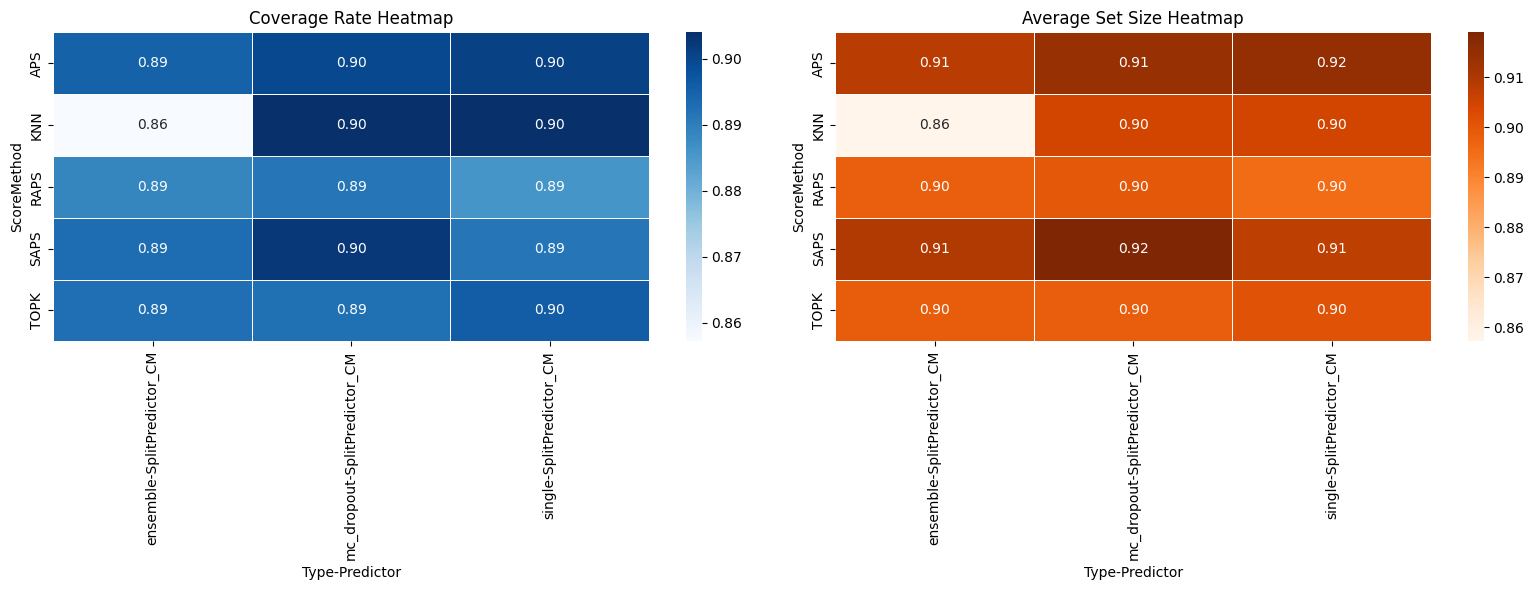

[INFO] Heatmaps saved to ../src/results/cp_resultats_heatmap.png


In [5]:
plot_heatmap(results_csv="../src/results/cp_results.csv", save_path="../src/results/cp_resultats_heatmap.png")

In [6]:
# plot_prediction_set_distribution(prediction_sets_csv="../src/results/prediction_sets.csv", save_path="../src/results/prediction_set_distribution.png")


In [7]:
df_prediction_set = pd.read_csv("../src/results/prediction_sets.csv")
df_prediction_set.head()

,Type,ScoreMethod,Predictor,True Labels,Prediction Sets,lengths
0,single,APS,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, set(), {1}, {0}, set(), set(), set(), {9...","[1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, ..."
1,single,RAPS,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[set(), {2}, {1}, {0}, {4}, {1}, {4}, {9}, {5}...","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ..."
2,single,SAPS,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, {2}, {1}, {0}, {4}, {1}, set(), {9}, {5}...","[1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,single,TOPK,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, set(), {1}, {0}, {4}, {1}, {4}, {9}, {5}...","[1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, ..."
4,single,KNN,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, {2}, {1}, {0}, {4}, {1}, {4}, {9}, set()...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ..."


In [8]:
df_lengths = pd.read_csv("../src/results/lengths.csv")
df_lengths.head()

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,1,0,1,1,0,0,0,1,1,0,...,1,1,1,1,1,1,1,1,1,1
1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,0,1,1,1,1,1,1
2,1,1,1,1,1,1,0,1,1,1,...,1,1,1,1,1,1,1,1,1,0
3,1,0,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,0,1,1,1
4,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1


In [9]:
import pandas as pd
df_lengths = df_lengths.reset_index(drop=True)
df_prediction_set = df_prediction_set.reset_index(drop=True)

df_combined = pd.concat([df_prediction_set, df_lengths], axis=1)
df_combined.head()


,Type,ScoreMethod,Predictor,True Labels,Prediction Sets,lengths,0,1,2,3,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,single,APS,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, set(), {1}, {0}, set(), set(), set(), {9...","[1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, ...",1,0,1,1,...,1,1,1,1,1,1,1,1,1,1
1,single,RAPS,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[set(), {2}, {1}, {0}, {4}, {1}, {4}, {9}, {5}...","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...",0,1,1,1,...,1,1,1,0,1,1,1,1,1,1
2,single,SAPS,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, {2}, {1}, {0}, {4}, {1}, set(), {9}, {5}...","[1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...",1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
3,single,TOPK,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, set(), {1}, {0}, {4}, {1}, {4}, {9}, {5}...","[1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, ...",1,0,1,1,...,1,1,1,1,1,1,0,1,1,1
4,single,KNN,SplitPredictor_CM,"[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, ...","[{7}, {2}, {1}, {0}, {4}, {1}, {4}, {9}, set()...","[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


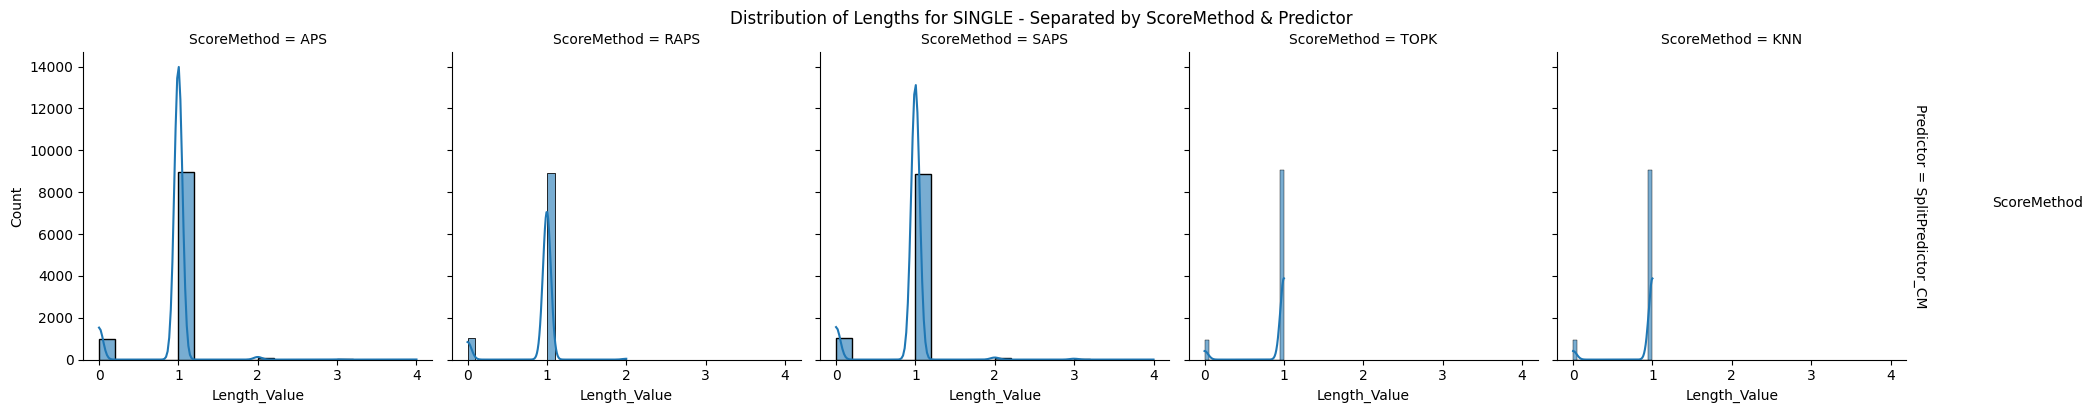

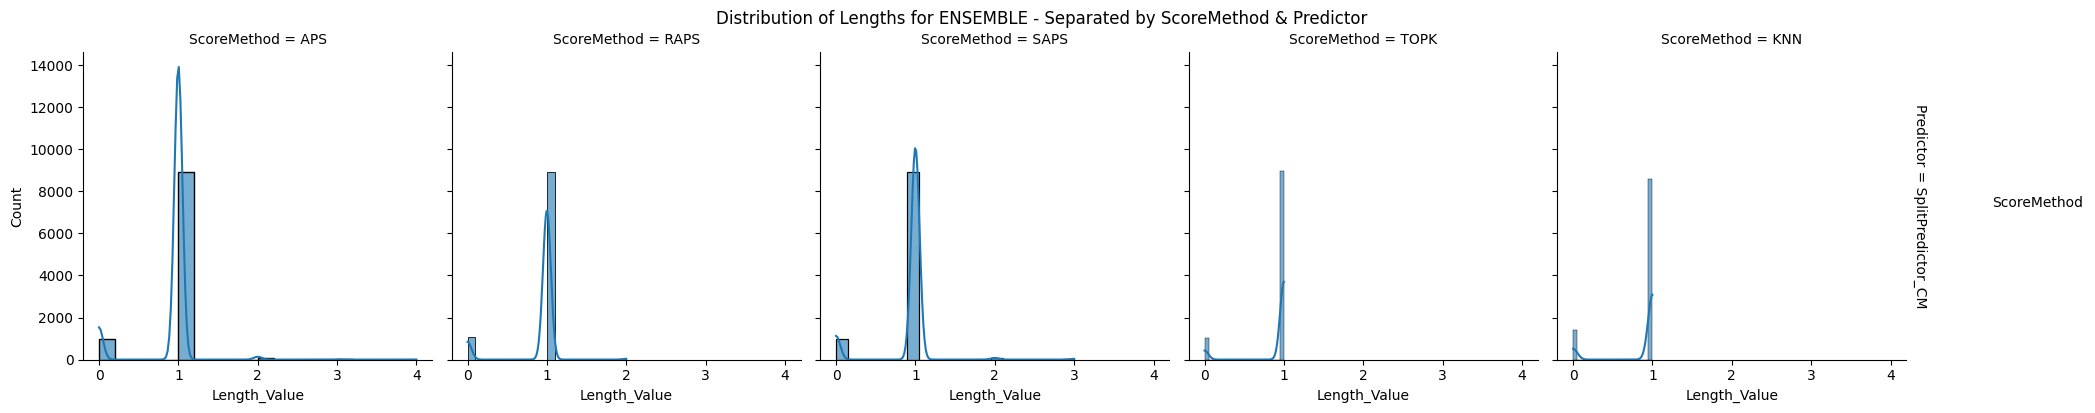

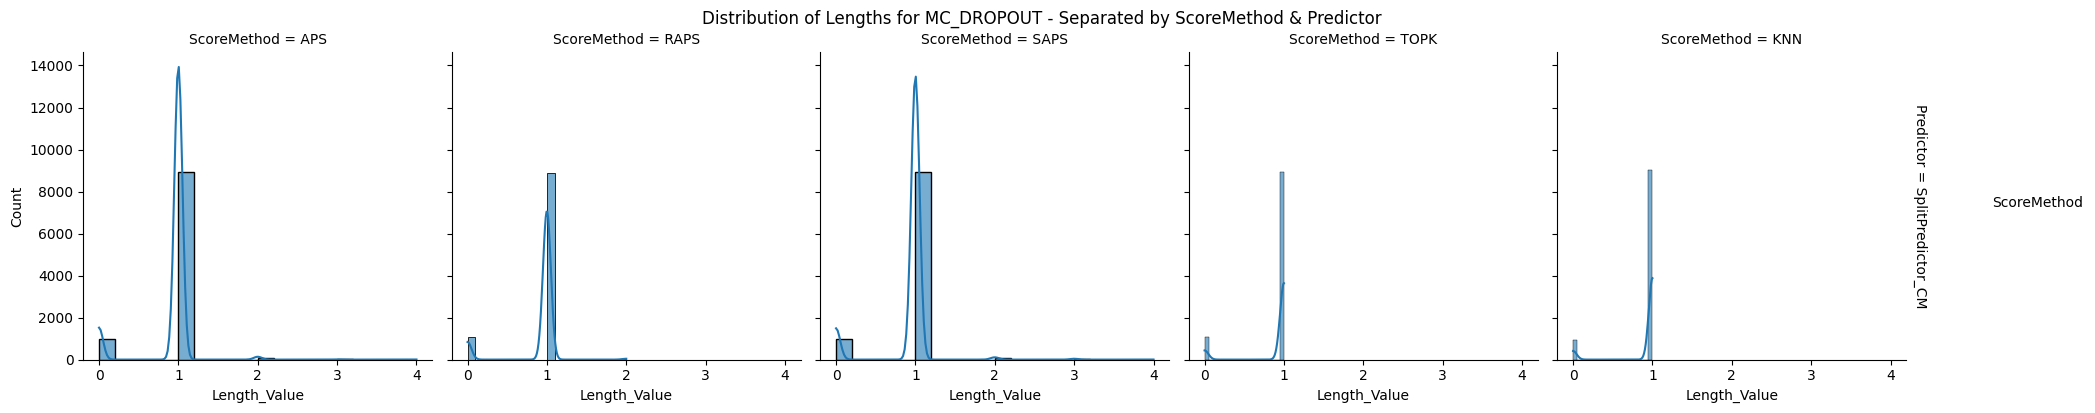

In [12]:
df_melted = df_combined.melt(
    id_vars=["Type", "ScoreMethod", "Predictor"], 
    var_name="Length_Index", 
    value_name="Length_Value"
)
df_melted["Length_Value"] = pd.to_numeric(df_melted["Length_Value"], errors="coerce")

unique_types = df_melted["Type"].unique()
for t in unique_types:
    df_subset = df_melted[df_melted["Type"] == t]

    g = sns.FacetGrid(df_subset, col="ScoreMethod", row="Predictor", margin_titles=True, height=4, sharex=True, sharey=True)
    g.map_dataframe(sns.histplot, x="Length_Value", bins=20, kde=True, alpha=0.6)
    g.add_legend(title="ScoreMethod")
    plt.suptitle(f"Distribution of Lengths for {t.upper()} - Separated by ScoreMethod & Predictor", y=1.02)
    plt.show()


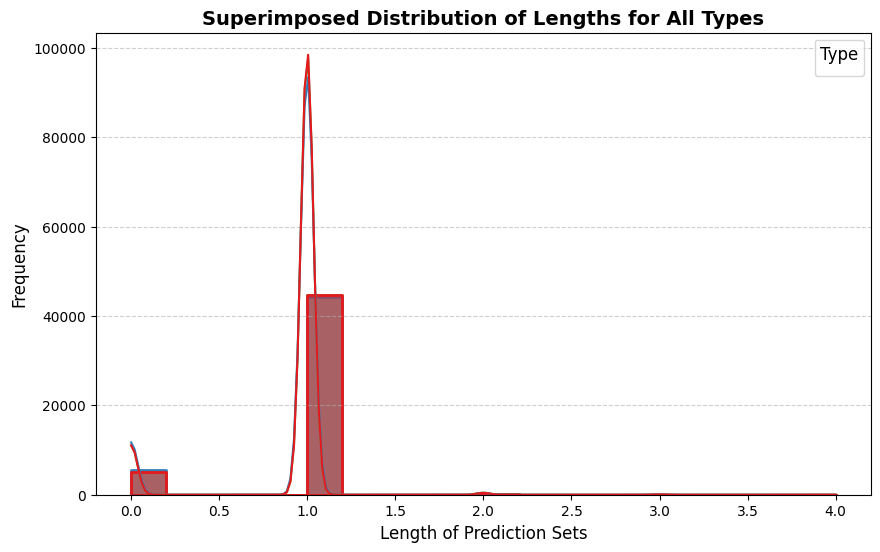

In [11]:
palette = sns.color_palette("Set1", n_colors=df_melted["Type"].nunique())

plt.figure(figsize=(10, 6))
ax1 = sns.histplot(
    data=df_melted, 
    x="Length_Value", 
    hue="Type", 
    bins=20, 
    kde=True, 
    alpha=0.5, 
    palette=palette, 
    element="step", 
    linewidth=2
)

plt.title("Superimposed Distribution of Lengths for All Types", fontsize=14, fontweight="bold")
plt.xlabel("Length of Prediction Sets", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)

handles, labels = ax1.get_legend_handles_labels()
plt.legend(handles, labels, title="Type", fontsize=10, title_fontsize=12, frameon=True)

plt.show()
